# Evaluation Demo: trained sentence-attention model on bundled example data

This notebook loads the trained model checkpoint shipped with the repo (`data/example/example_model.pt`), runs inference on the 10 bundled example documents (`data/example/example_documents.json` + `example_embeddings.pt`), and produces the same metrics and figure types used in the project's results section.

Everything imports from the project package (`transcripts_fed_vix.*`); nothing in this notebook re-implements model code.

## Install the project package

If `pip install -e .` has already been run in this kernel's Python, the next cell is a no-op.

In [1]:
import sys, subprocess
from pathlib import Path

# Find repo root by walking up until we see pyproject.toml.
_here = Path.cwd()
for candidate in [_here, *list(_here.parents)]:
    if (candidate / 'pyproject.toml').exists():
        repo_root = candidate
        break
else:
    raise RuntimeError('Could not find repo root: no pyproject.toml in CWD or any parent directory.')

try:
    import transcripts_fed_vix  # noqa: F401
    print(f'Package already installed in this kernel.')
except ModuleNotFoundError:
    print(f'Installing transcripts_fed_vix from {repo_root} ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-e', str(repo_root)])
    print('Done. Restart the kernel if imports below fail.')

Package already installed in this kernel.


## 1. Load the bundled example documents and the trained model

Both live in `data/example/` and are committed to the repo so this notebook runs offline.

In [2]:
import torch
from transcripts_fed_vix.data import load_example_documents, get_example_dataloader
from transcripts_fed_vix.models import SentenceAttentionModel
from transcripts_fed_vix.models.attention import AttentionConfig

documents = load_example_documents()
loader = get_example_dataloader(batch_size=10)  # tiny set; one batch covers it

model_path = repo_root / 'data' / 'example' / 'example_model.pt'
model = SentenceAttentionModel(AttentionConfig())
model.load_state_dict(torch.load(model_path, map_location='cpu', weights_only=True))
model.eval()

print(f'Loaded {len(documents)} example documents.')
print(f'Trained-component parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Loaded 10 example documents.
Trained-component parameters: 99,329


## 2. Run inference and compute regression metrics

Same `regression_metrics` helper used during training and per-regime evaluation. With only 10 documents and a model trained on a tiny demo subset, R^2 can be very low or negative; that is expected.

In [3]:
import numpy as np
from transcripts_fed_vix.training.eval import regression_metrics

preds = []
tgts = []
doc_ids = []
release_dates = []
with torch.no_grad():
    for batch in loader:
        out = model(batch['embeddings'], batch['mask'])
        preds.extend(out.prediction.tolist())
        tgts.extend(batch['target'].tolist())
        doc_ids.extend(batch['doc_ids'])
        release_dates.extend(batch['release_dates'])

preds_arr = np.asarray(preds)
tgts_arr = np.asarray(tgts)
metrics = regression_metrics(preds_arr, tgts_arr)
print('Demo-subset metrics:')
for k, v in metrics.to_dict().items():
    print(f'  {k:>12s}: {v}')

Demo-subset metrics:
           mse: 3.6103912233792363
            r2: -0.33247921838632033
     pearson_r: 0.09913359502527339
     pearson_p: 0.785263857466265
             n: 10


## 3. Predicted vs actual (single panel)

Same idea as `outputs/figures/predicted_vs_actual.png` but for the 10 demo docs.

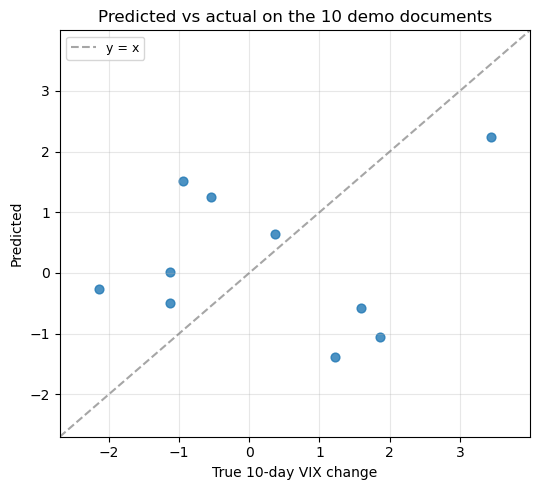

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(tgts_arr, preds_arr, s=40, alpha=0.8)
lo = float(min(tgts_arr.min(), preds_arr.min()))
hi = float(max(tgts_arr.max(), preds_arr.max()))
pad = 0.1 * (hi - lo + 1e-9)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color='gray', linestyle='--', alpha=0.7, label='y = x')
ax.set_xlim(lo - pad, hi + pad)
ax.set_ylim(lo - pad, hi + pad)
ax.set_xlabel('True 10-day VIX change')
ax.set_ylabel('Predicted')
ax.set_title('Predicted vs actual on the 10 demo documents')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Residuals over time

Residual = target minus prediction. Vertical lines mark the three regime boundaries used in the full-corpus evaluation: 2017-01-20, 2021-01-20, 2025-01-20.

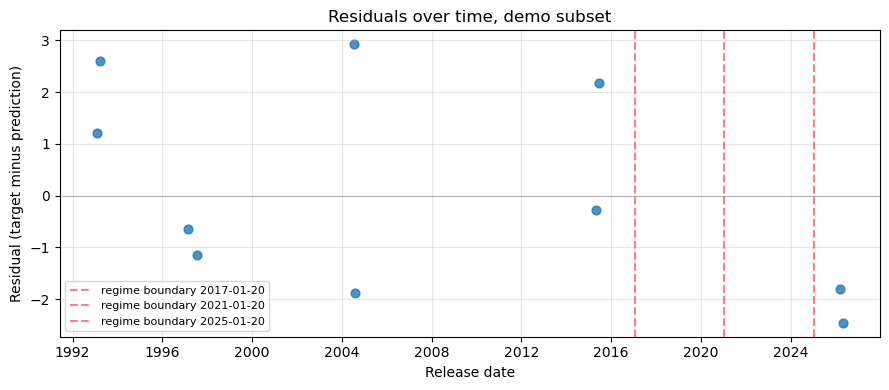

In [5]:
import pandas as pd

resid = tgts_arr - preds_arr
dates = pd.to_datetime(release_dates)

fig, ax = plt.subplots(figsize=(9, 4))
ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
ax.scatter(dates, resid, s=40, alpha=0.8)
for bp in ['2017-01-20', '2021-01-20', '2025-01-20']:
    ax.axvline(pd.Timestamp(bp), color='red', linestyle='--', alpha=0.5, label=f'regime boundary {bp}')
ax.set_xlabel('Release date')
ax.set_ylabel('Residual (target minus prediction)')
ax.set_title('Residuals over time, demo subset')
handles, labels_l = ax.get_legend_handles_labels()
seen = set()
keep = [(h, l) for h, l in zip(handles, labels_l) if not (l in seen or seen.add(l))]
ax.legend(*zip(*keep), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Attention-weight inspection

For one chosen document, show the top-attended sentences. The attention head is the only interpretable component of the model and is the main qualitative output of the project.

In [6]:
# Pick the most recent document for inspection.
loader_iter = iter(get_example_dataloader(batch_size=10))
batch = next(loader_iter)
with torch.no_grad():
    out = model(batch['embeddings'], batch['mask'])

# Find the index of the most recent doc in this batch.
i_recent = int(np.argmax([d.toordinal() for d in batch['release_dates']]))
doc_id = batch['doc_ids'][i_recent]
n_real = int(batch['mask'][i_recent].sum())
attn = out.attention_weights[i_recent, :n_real].cpu().numpy()
sents = list(documents.set_index('doc_id').loc[doc_id, 'sentences'])[:n_real]

order = np.argsort(-attn)[:5]
print(f'Document: {doc_id} (release {batch["release_dates"][i_recent]})')
print(f'  target  = {batch["target"][i_recent].item():+.3f}')
print(f'  predict = {out.prediction[i_recent].item():+.3f}')
print('  Top-5 attended sentences:')
for rank, idx in enumerate(order, start=1):
    snippet = sents[idx][:160]
    print(f'    {rank}. weight={attn[idx]:.3f}  {snippet}')

Document: fomc_20260429 (release 2026-04-29 00:00:00)
  target  = -0.940
  predict = +1.518
  Top-5 attended sentences:
    1. weight=0.994  The manager next considered equity market developments.
    2. weight=0.004  Near-term inflation expectations, as reported in the Open Market Desk Survey of Market Expectations (Desk survey), had again moved up, though expectations for 2
    3. weight=0.002  The manager noted, however, that the curve's forecasting record was mixed.
    4. weight=0.000  The curve remained steeply downward sloping, consistent with investor expectations of oil prices falling considerably in coming months.
    5. weight=0.000  In discussing credit markets, the manager noted that the private credit sector continued to receive attention over the intermeeting period.


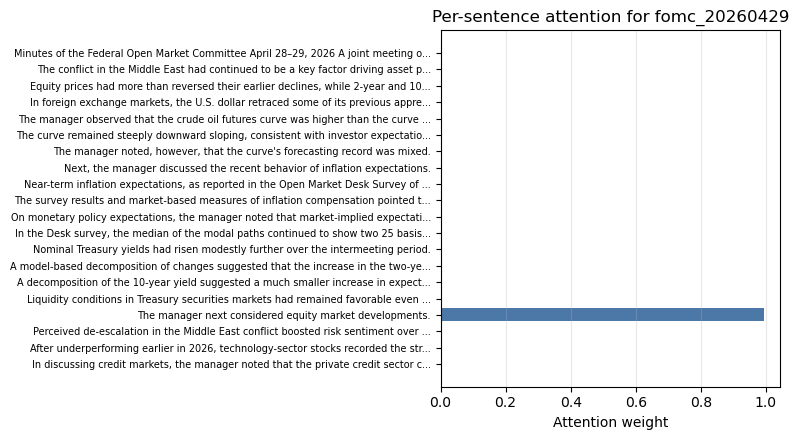

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(np.arange(n_real), attn, color='#4C78A8')
ax.invert_yaxis()
ax.set_yticks(np.arange(n_real))
labels = [(s[:80] + '...') if len(s) > 80 else s for s in sents]
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('Attention weight')
ax.set_title(f'Per-sentence attention for {doc_id}')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Next steps

- Full-corpus per-regime metrics: see `outputs/final_report.json` after running the Talapas job.
- The five canonical project figures land in `outputs/figures/` and are documented in the README's results section.

## 6. Reported full-corpus results

The cells above run the trained model on the 10 bundled demo documents. The numbers and figures in the README's Results section come from the full Talapas run, whose metrics and figures are committed under `outputs/`. This section loads those committed artifacts so the notebook reproduces exactly what the README reports.

           segment  n  model_r  model_p  model_mse  baseline_r
               Val 35    0.341    0.045        6.6         NaN
Regime 1 (Trump 1) 40    0.075    0.646       45.2       0.139
  Regime 2 (Biden) 40    0.167    0.304       21.7       0.060
Regime 3 (Trump 2) 13    0.331    0.270        3.0      -0.008
       Pooled test 93    0.110    0.296       29.2         NaN

Direction classifier (pooled): accuracy=0.467, AUC=0.511, majority-class baseline=0.511
Predictions barely move: pred std=1.19 vs target std=5.40


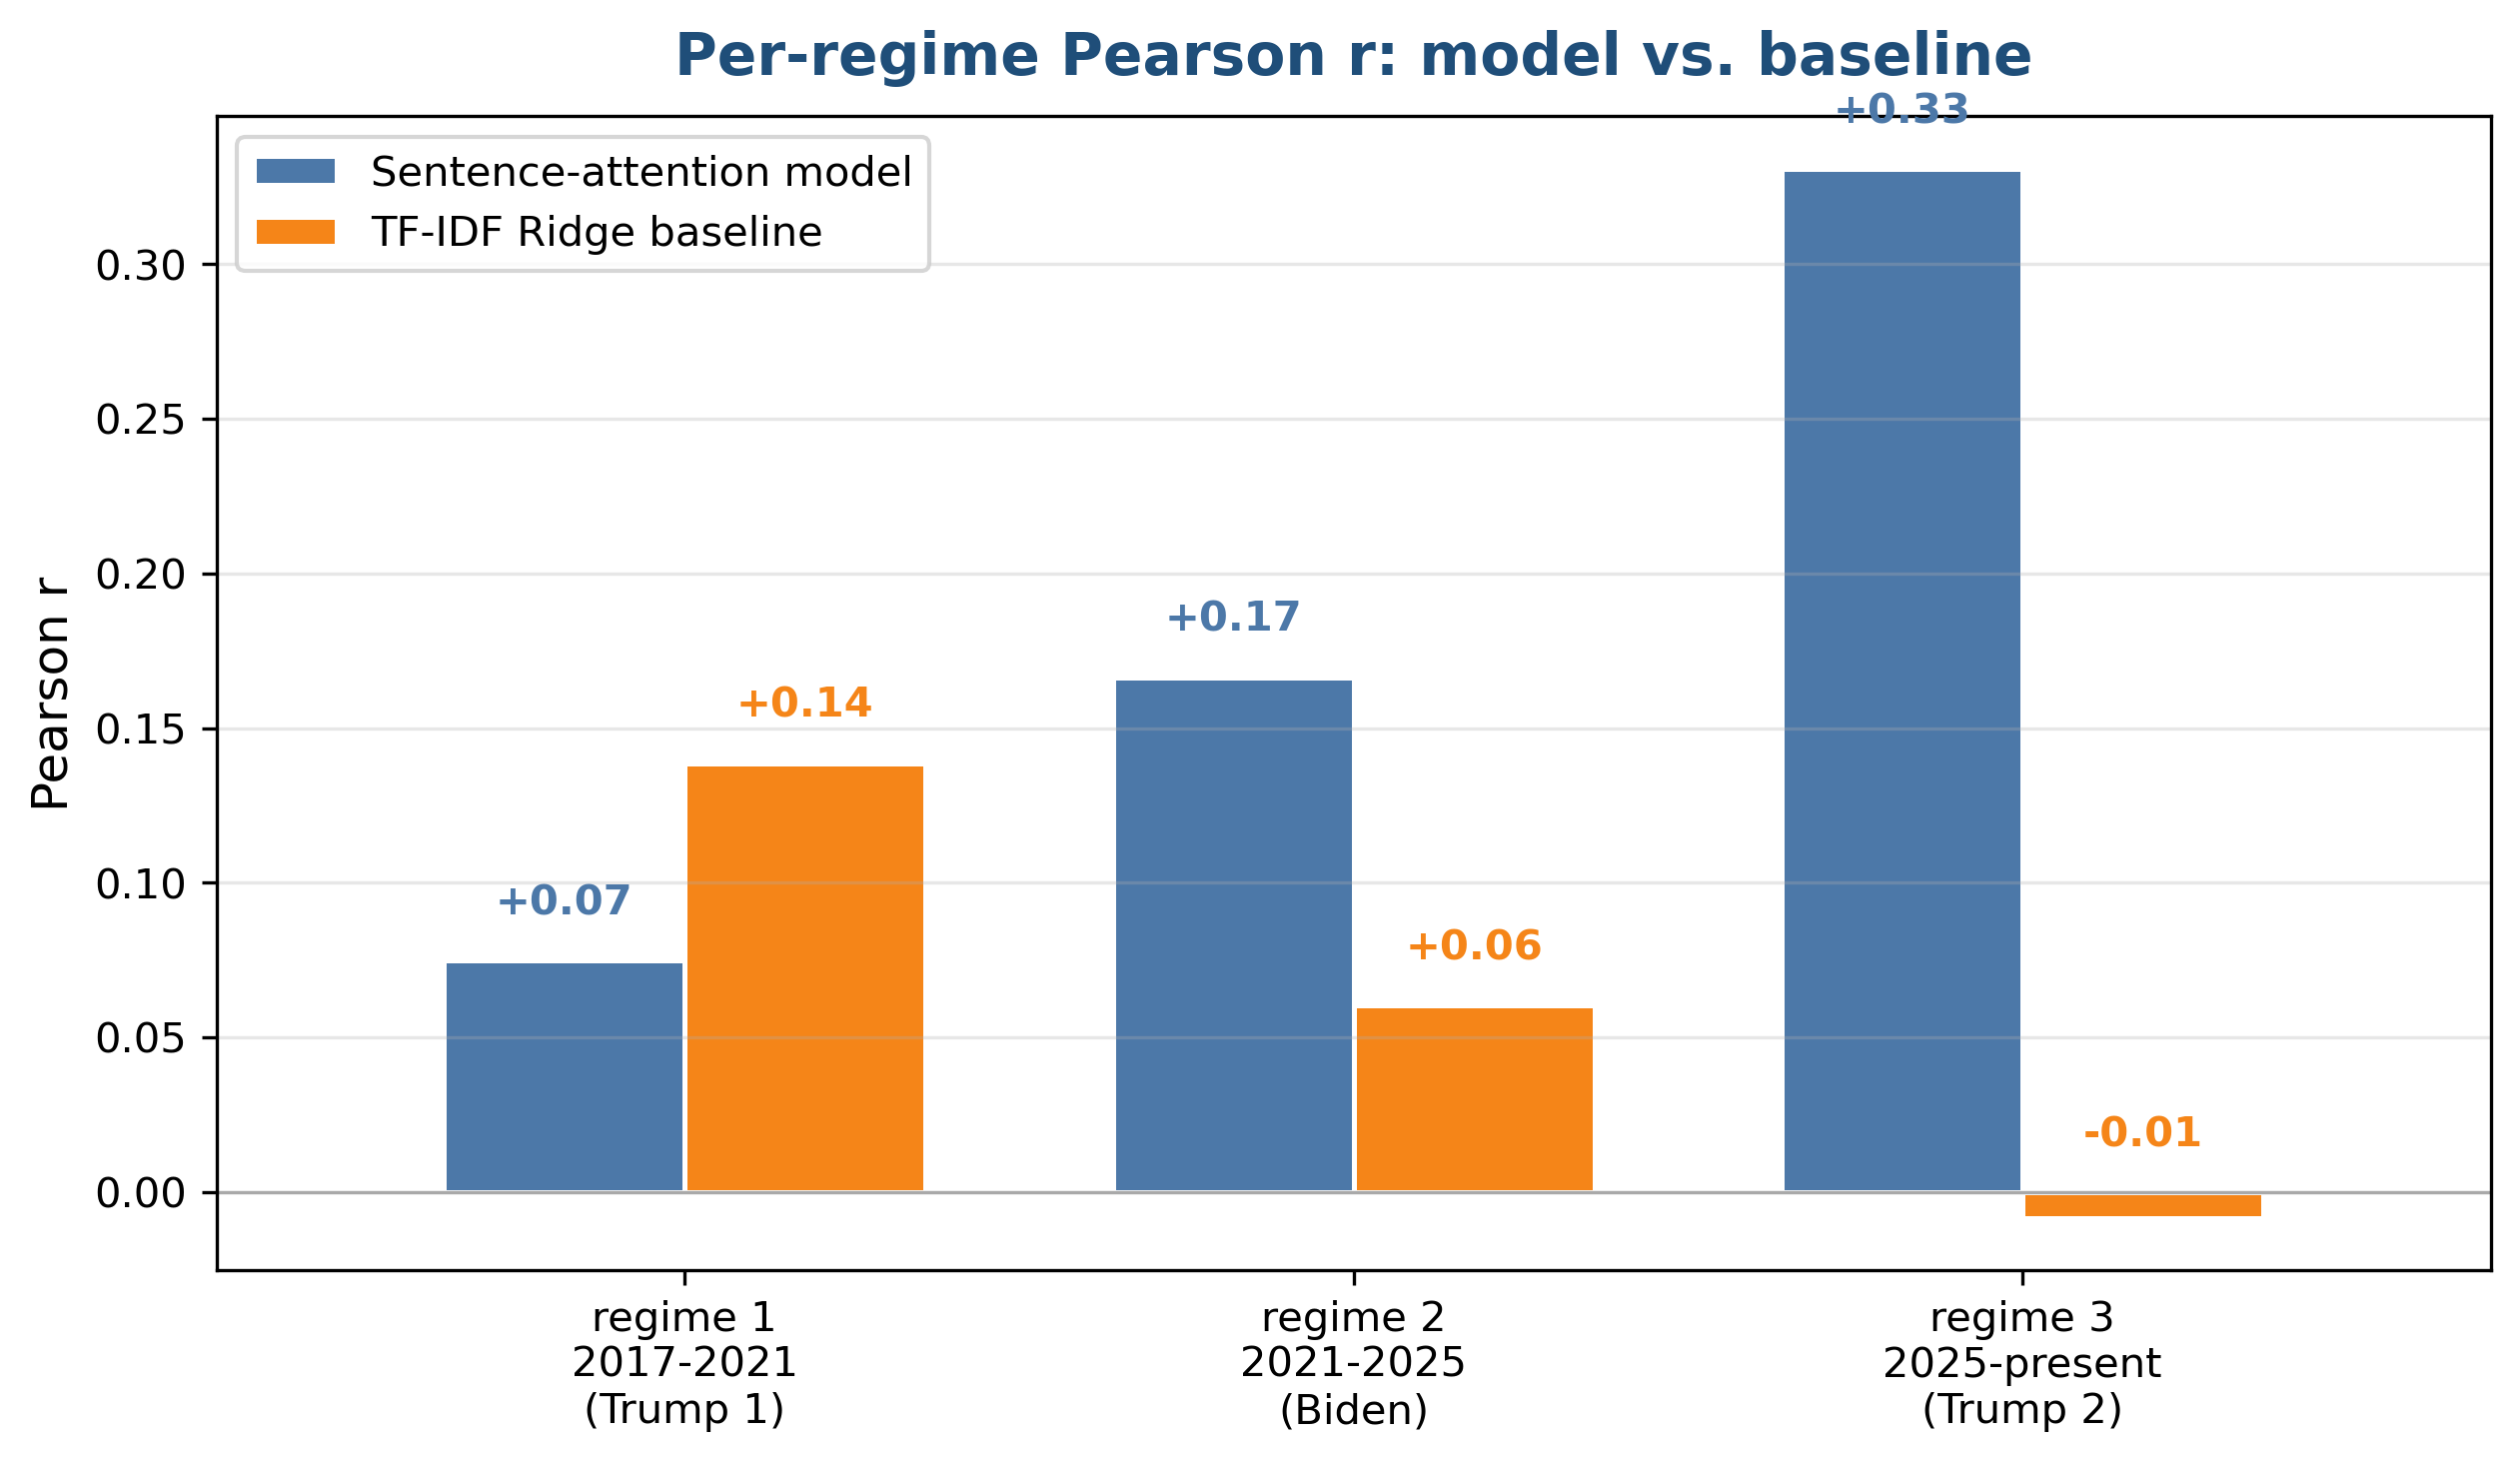

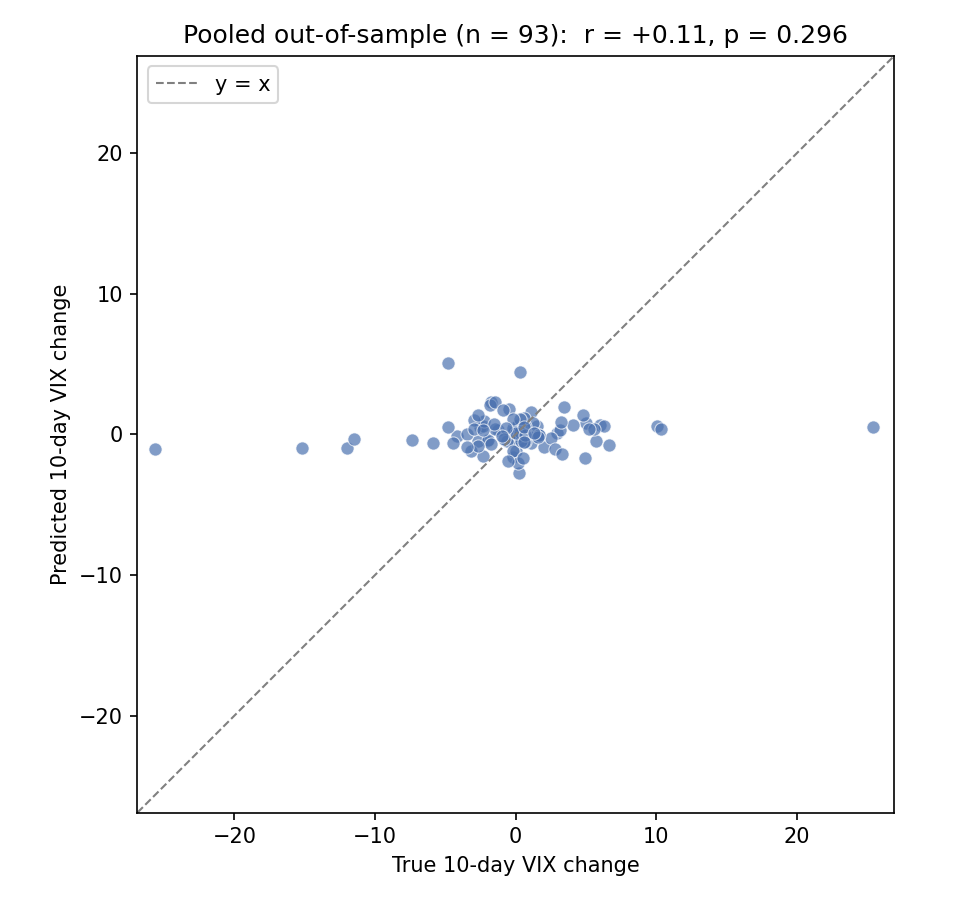

In [8]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

_root = Path.cwd()
while not (_root / 'pyproject.toml').exists() and _root != _root.parent:
    _root = _root.parent
OUT = _root / 'outputs'

fr = json.loads((OUT / 'final_report.json').read_text())
bl = json.loads((OUT / 'baseline_metrics.json').read_text())
fe = json.loads((OUT / 'final_eval.json').read_text())

segs = [('Val', 'val'), ('Regime 1 (Trump 1)', 'regime1_2017_2021'),
        ('Regime 2 (Biden)', 'regime2_2021_2025'), ('Regime 3 (Trump 2)', 'regime3_2025_present')]
rows = []
for name, key in segs:
    m = fr[key]['regression']
    b = bl.get(key, {}).get('tfidf_ridge', {})
    rows.append({'segment': name, 'n': m['n'], 'model_r': round(m['pearson_r'], 3),
                 'model_p': round(m['pearson_p'], 3), 'model_mse': round(m['mse'], 1),
                 'baseline_r': round(b['pearson_r'], 3) if b else None})
p = fe['part_a_pooled_regression']['pooled_regression']
rows.append({'segment': 'Pooled test', 'n': p['n'], 'model_r': round(p['pearson_r'], 3),
             'model_p': round(p['pearson_p'], 3), 'model_mse': round(p['mse'], 1), 'baseline_r': None})
results = pd.DataFrame(rows)
print(results.to_string(index=False))

clf = fe['part_b_directional_classifier']
print(f"\nDirection classifier (pooled): accuracy={clf['accuracy']:.3f}, "
      f"AUC={clf['auc']:.3f}, majority-class baseline={clf['majority_class_baseline']:.3f}")
print(f"Predictions barely move: pred std={fe['part_a_pooled_regression']['prediction_std']:.2f} "
      f"vs target std={fe['part_a_pooled_regression']['target_std']:.2f}")

for fig in ['regression_pearson_only.png', 'pooled_predicted_vs_actual.png']:
    display(Image(filename=str(OUT / 'figures' / fig)))